In [1]:
import sys
import numpy as np
import os
import json
import shutil

# Add the directory containing instruments.py to the Python path
custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
sys.path.append(custom_module_path)

import plotting_rewrite as plotting
import instruments_jax as inst

h5_original_file_path = "/home/rebeccaz/Github/vampires_calibration/mcmc/results/720nm_Adjusted_EM_Gain_with_IMR_offset_Angles_PM45_Shared_Priors_20000000_steps.h5"
h5_file_path = "/home/rebeccaz/Github/vampires_calibration/mcmc/results/720nm_Adjusted_EM_Gain_with_IMR_offset_Angles_PM45_Shared_Priors_20000000_steps_copy.h5"
shutil.copy2(h5_original_file_path, h5_file_path)
txt_file_path = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/720_with_IMR_offset_pm_1_degree_fixed_EM_gain_with_dichroic_best_fit_old_fit_values.txt"
txt_save_file_path = "/home/rebeccaz/Github/vampires_calibration/mcmc/results/720nm_Adjusted_EM_Gain_with_IMR_offset_Angles_PM45_Shared_Priors_20000000_steps.txt"

# Step 1: Defining System Dictionary

In [2]:
filter_wavelength = 720
wavelength_string = filter_wavelength
wavelength_index = 2
nsteps = 20000000
obs_mode = "MBI"

IPOL_em_gains = [1.14, 1.18, 1.18, 1.18]
MBI_em_gains = [1.23, 1.19, 1.2, 1.08]
if obs_mode == "IPOL":
    em_gain = IPOL_em_gains[wavelength_index]
elif obs_mode == "MBI":
    em_gain = MBI_em_gains[wavelength_index]

system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta" : 0},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta": 0},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": 0},
        },
    }
}

# Step 2: Loading Chains

dichroic.phi (waves): -0.03315 ± 0.69339
dichroic.epsilon (): 0.00310 ± 0.00383
dichroic.theta (): 4.59311 ± 17.95460
flc.phi (waves): 0.50423 ± 0.04352
flc.delta_theta (): -1.36904 ± 3.38402
optics.phi (waves): 0.27345 ± 0.06404
optics.epsilon (): 0.01629 ± 0.00798
optics.theta (): -20.10689 ± 7.62600
image_rotator.phi (waves): 0.47864 ± 0.00202
image_rotator.delta_theta (): -0.29024 ± 0.99729
hwp.phi (waves): 0.49440 ± 0.00222
hwp.delta_theta (): 10.02702 ± 2.09653
lp.theta (): -3.47146 ± 3.55140
log_f (): -3.56829 ± 0.08162
Chain shape (nsteps, nwalkers, ndim): (1303969, 28, 14)


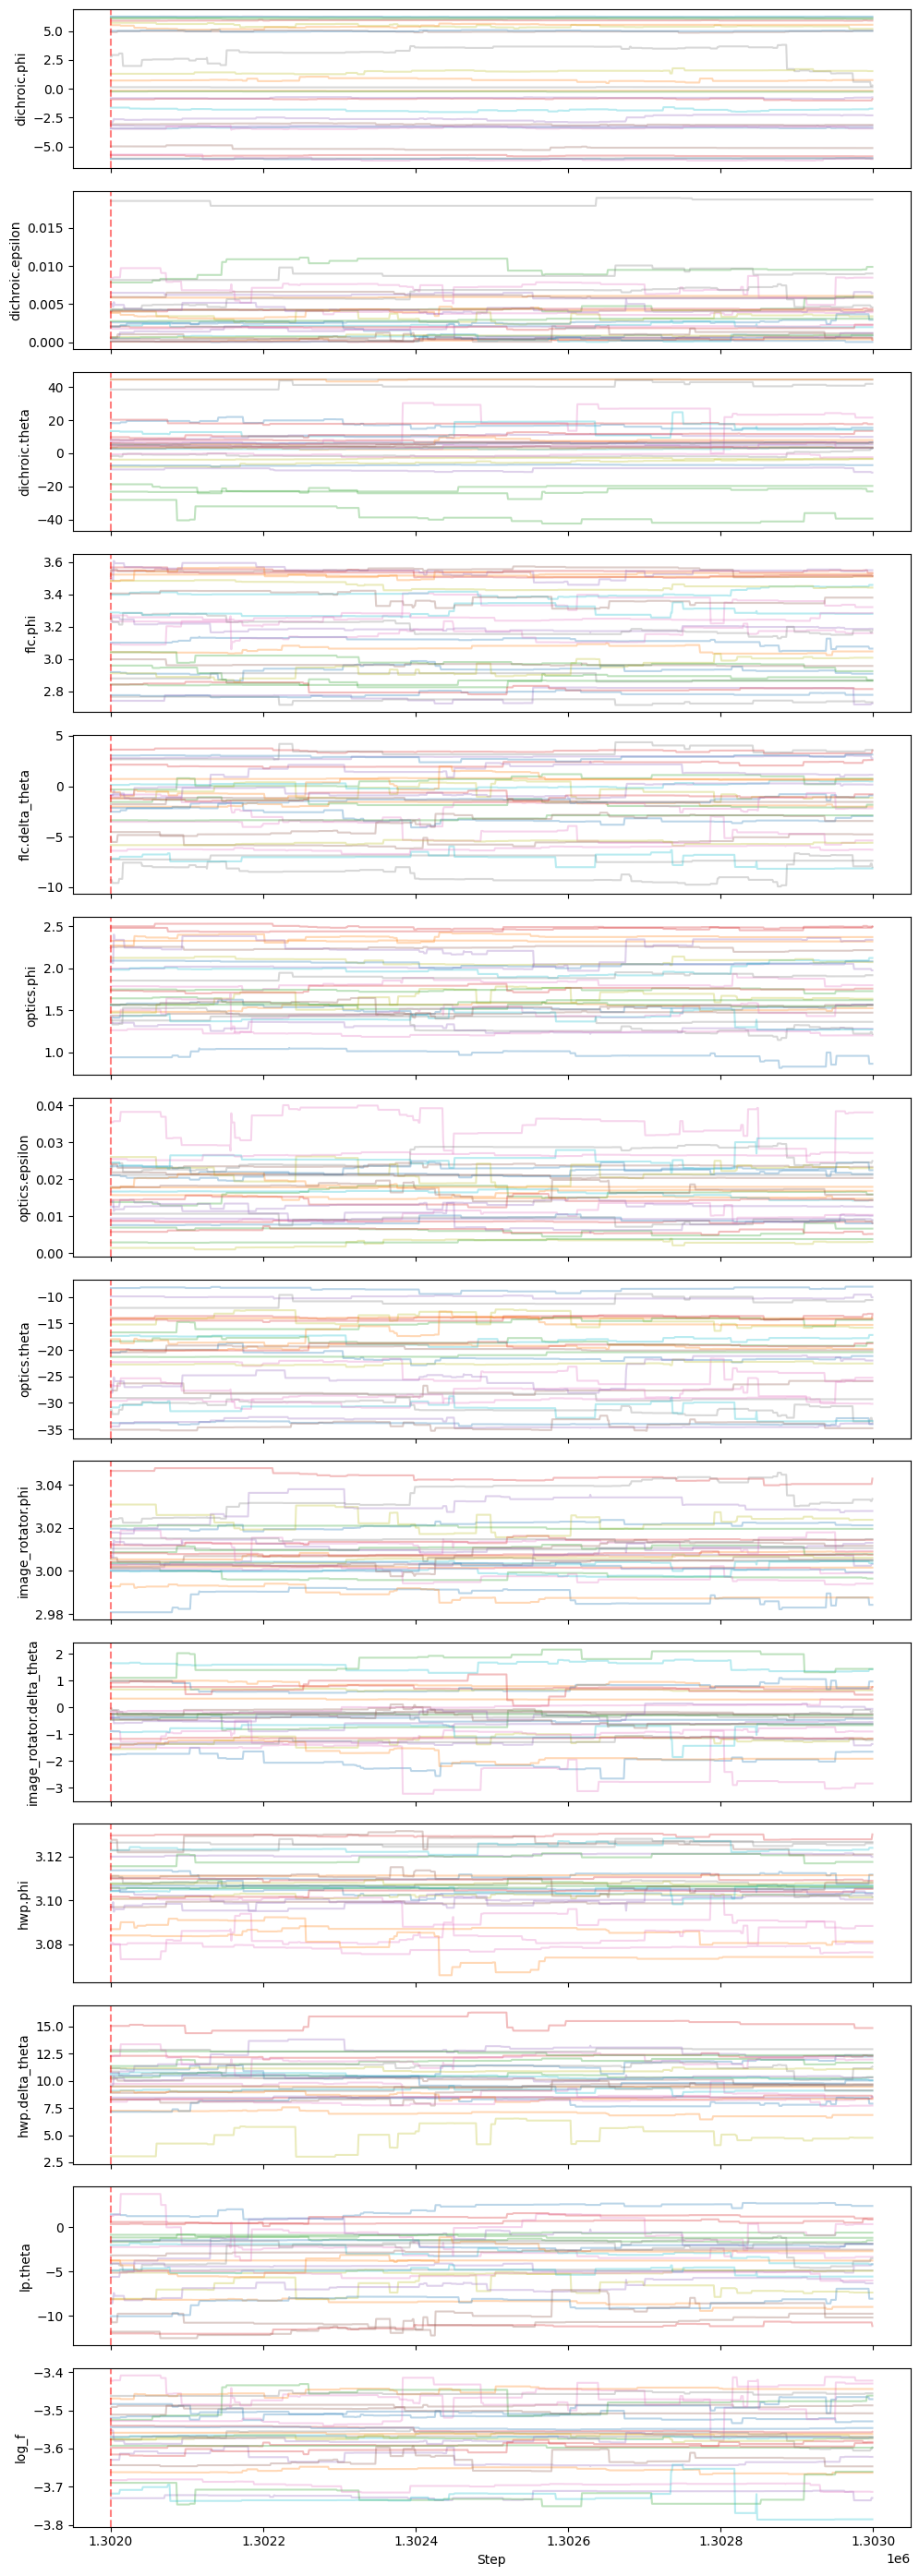

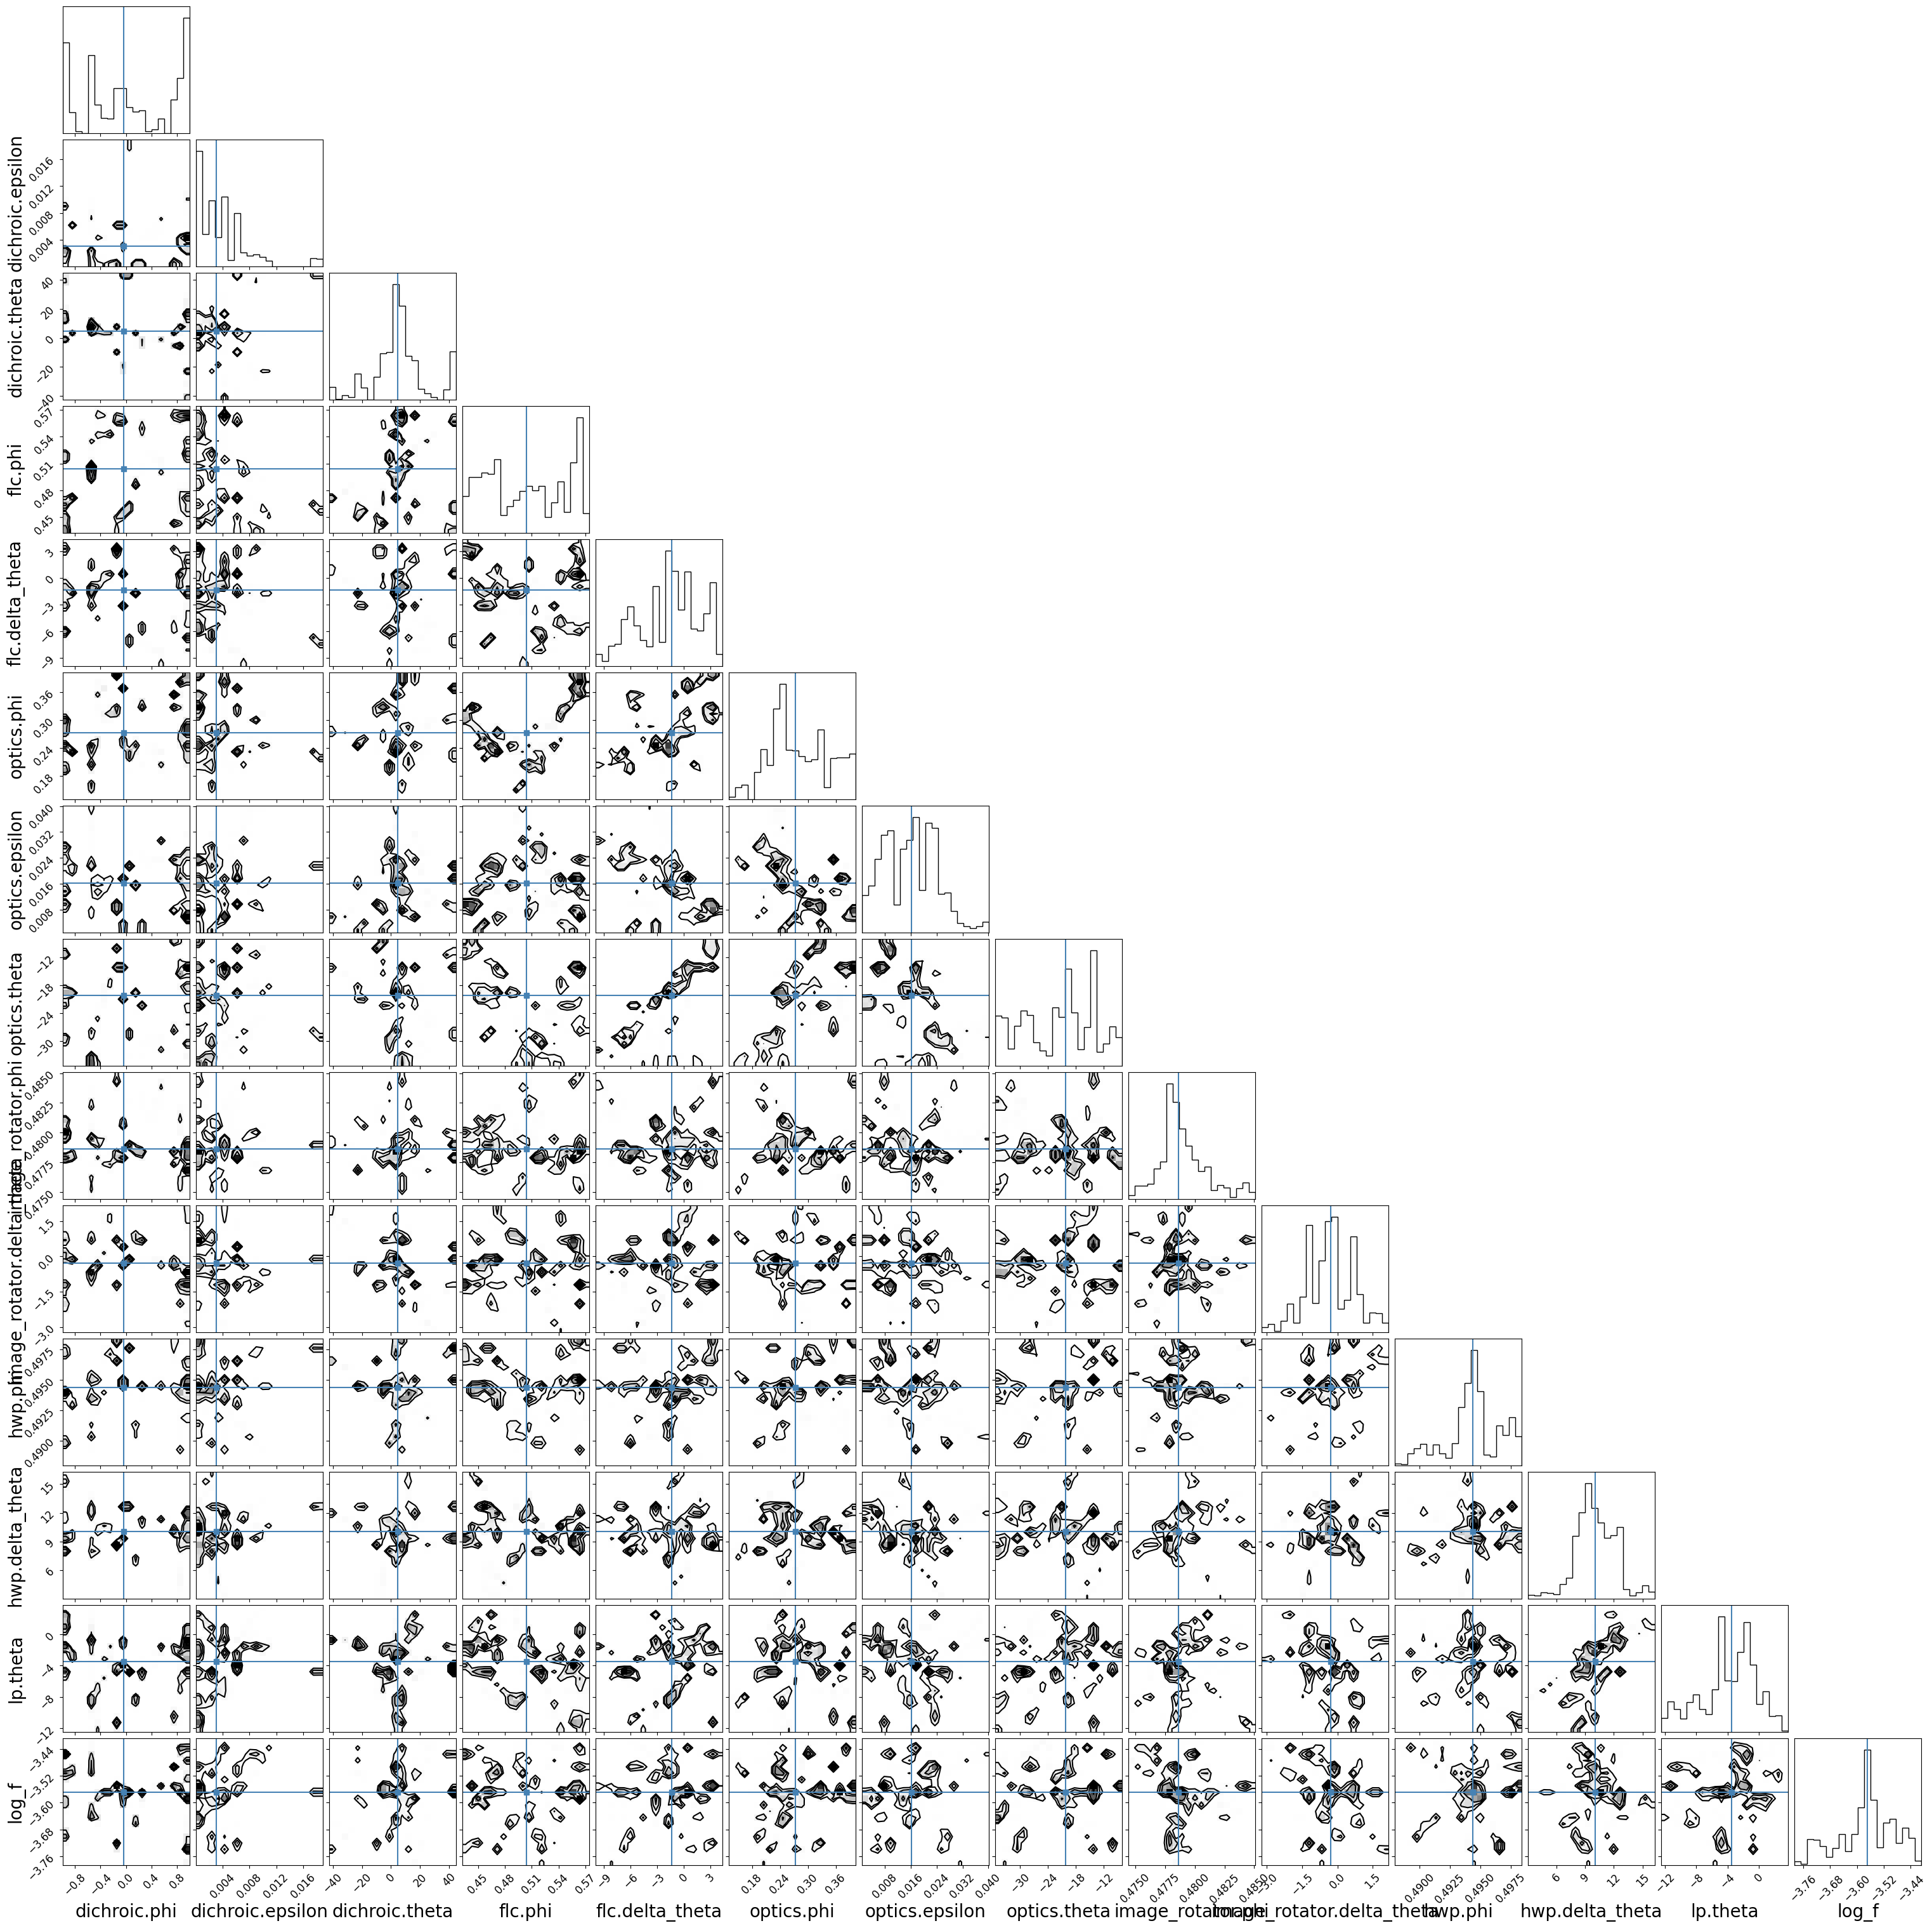

In [3]:
chain, names = plotting.load_chain_and_labels(h5_file_path, txt_file_path, include_logf = True, copy_file=True)
chain_step_range = (1302000, 1303000)
corner_plot_step_range = (1302000, 1303000)

# Print median ± std for each parameter
plotting.summarize_posteriors(chain, names, system_dict, step_range=corner_plot_step_range, 
    txt_save_file_path = txt_save_file_path, txt_file_path = txt_file_path)

# Check chain shape after loading
print("Chain shape (nsteps, nwalkers, ndim):", chain.shape)

# Plot trace plots for MCMC chains
plotting.plot_trace(chain, names, step_range=chain_step_range, max_walkers=100)

# Plot corner plot from flattened chain
plotting.plot_corner_flat(chain, names, step_range=corner_plot_step_range)


## Step 2.5: Autocorrelation Time Diagnostics

In [ ]:
import emcee

# Use the full loaded chain by default. Set a different range to estimate tau after burn-in.
autocorr_step_range = (0, None)
autocorr_thin = 1
autocorr_tol = 0  # Use 50 for emcee's usual convergence check; 0 always returns an estimate.

act_start, act_end = autocorr_step_range
if act_end is None:
    act_end = chain.shape[0]

if act_start < 0 or act_end > chain.shape[0] or act_start >= act_end:
    raise ValueError(f"Invalid autocorr_step_range {autocorr_step_range} for chain with {chain.shape[0]} steps.")

act_chain = chain[act_start:act_end:autocorr_thin, :, :]
if act_chain.shape[0] < 2:
    raise ValueError("Autocorrelation calculation needs at least two saved steps.")

autocorr_tau = emcee.autocorr.integrated_time(act_chain, tol=autocorr_tol, quiet=True)
autocorr_tau_steps = autocorr_tau * autocorr_thin
autocorr_nsteps = act_end - act_start
autocorr_neff = act_chain.shape[0] * act_chain.shape[1] / autocorr_tau
recommended_burn_in = int(2 * np.max(autocorr_tau_steps))
recommended_thinning = max(1, int(0.5 * np.min(autocorr_tau_steps)))

print(f"Autocorrelation step range: {act_start} to {act_end} (thin={autocorr_thin})")
print(f"{'parameter':<35} {'tau [steps]':>12} {'nsteps/tau':>12} {'N_eff':>12}")
for name, tau_steps, neff in zip(names, autocorr_tau_steps, autocorr_neff):
    print(f"{name:<35} {tau_steps:12.1f} {autocorr_nsteps / tau_steps:12.1f} {neff:12.0f}")

print(f"Mean tau: {np.mean(autocorr_tau_steps):.1f} steps")
print(f"Max tau: {np.max(autocorr_tau_steps):.1f} steps")
print(f"Recommended burn-in: {recommended_burn_in} steps")
print(f"Recommended thinning: {recommended_thinning} steps")


# Step 2.6: Apply Recommended Burn-in and Thinning


In [ ]:
burn_in = recommended_burn_in
thinning = recommended_thinning

if burn_in < 0 or burn_in >= chain.shape[0]:
    raise ValueError(f"Invalid burn_in {burn_in} for chain with {chain.shape[0]} steps.")
if thinning < 1:
    raise ValueError(f"Invalid thinning {thinning}; thinning must be >= 1.")

posterior_chain = chain[burn_in::thinning, :, :]
posterior_step_numbers = np.arange(burn_in, chain.shape[0], thinning)
if posterior_chain.shape[0] < 1:
    raise ValueError("No posterior samples remain after applying burn-in and thinning.")

chain_step_range = (0, None)
corner_plot_step_range = (0, None)

print(f"Using burn-in = {burn_in} saved steps and thinning = {thinning} saved steps.")
print("Posterior chain shape (nthinned_steps, nwalkers, ndim):", posterior_chain.shape)
print(
    f"Original saved steps included: {posterior_step_numbers[0]} to "
    f"{posterior_step_numbers[-1]} ({posterior_chain.shape[0]} thinned samples per walker)."
)

# Print posterior summary for the thinned chain and save the median-fit text file.
plotting.summarize_posteriors(
    posterior_chain,
    names,
    system_dict,
    step_range=corner_plot_step_range,
    txt_save_file_path=txt_save_file_path,
    txt_file_path=txt_file_path,
)

# Plot trace plots after burn-in/thinning.
plotting.plot_trace(posterior_chain, names, step_range=chain_step_range, max_walkers=100)

# Plot corner plot from the flattened thinned posterior chain.
plotting.plot_corner_flat(posterior_chain, names, step_range=corner_plot_step_range)


# Step 3: Plot median configuration of posteriors

In [5]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)

In [6]:
# Loading in median parameters
with open(txt_save_file_path, "r") as f:
    past_fit = json.load(f)

# print(past_fit)

theta_pol = past_fit["lp"]["theta"]
delta_HWP = past_fit["hwp"]["phi"] 
offset_HWP = past_fit["hwp"]["delta_theta"]
delta_derot = past_fit["image_rotator"]["phi"] 
offset_derot = past_fit["image_rotator"].get("delta_theta", 0)
delta_opts = past_fit["optics"]["phi"]
epsilon_opts = past_fit["optics"]["epsilon"]
rot_opts = past_fit["optics"]["theta"]
delta_FLC = past_fit["flc"]["phi"] 
rot_FLC = past_fit["flc"]["delta_theta"]
delta_dichroic = past_fit["dichroic"]["phi"]
epsilon_dichroic = past_fit["dichroic"]["epsilon"]
rot_dichroic = past_fit["dichroic"]["theta"]

print(delta_HWP)

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary

system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {
                "phi": delta_dichroic * 2 * np.pi,
                "epsilon": epsilon_dichroic,
                "theta": rot_dichroic,
            },
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_FLC * 2 * np.pi,
                "theta": 0,  # not fitted
                "delta_theta": rot_FLC,
            },
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {
                "phi": delta_opts * 2 * np.pi,
                "epsilon": epsilon_opts,
                "theta": rot_opts,
            },
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_derot * 2 * np.pi,
                "theta": 0,  # not fitted
                "delta_theta": offset_derot,
            },
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_HWP * 2 * np.pi,
                "theta": 0,  # not fitted
                "delta_theta": offset_HWP,
            },
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        },
    }
}

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())


0.4944036691183934
[[ 0.53605291  0.53212206 -0.06479842  0.        ]
 [ 0.53605291  0.53212206 -0.06479842  0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]


logl value: 802.9653192857918


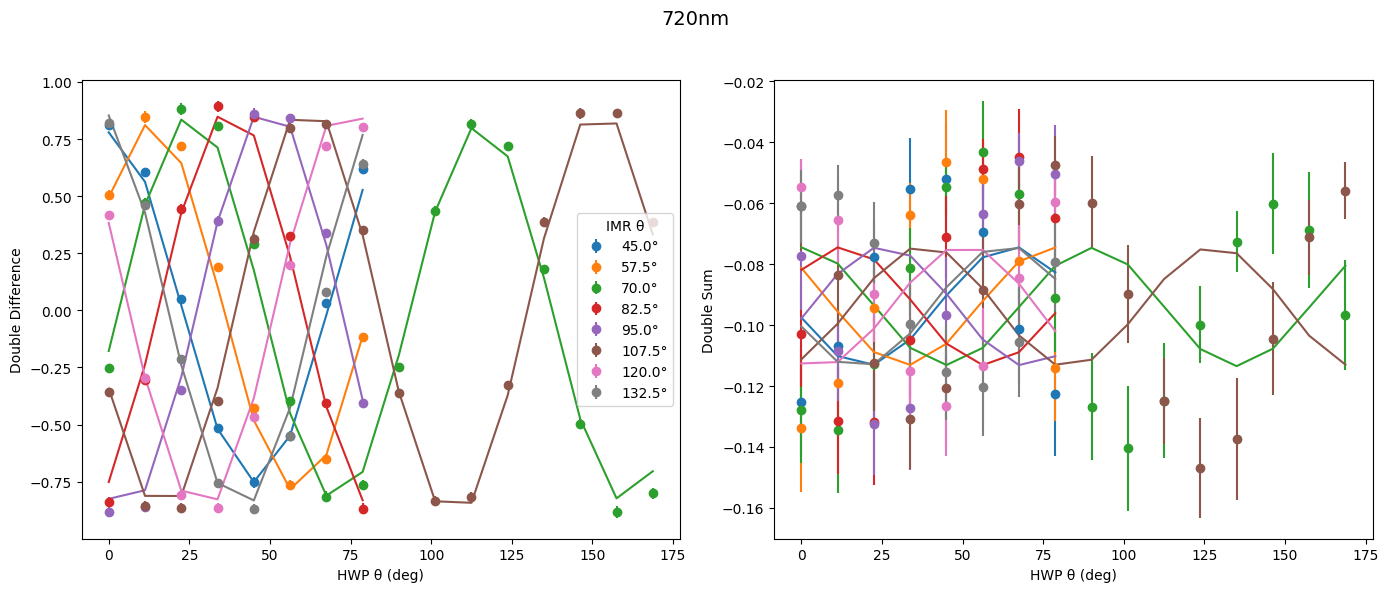

In [7]:
# Fittin for all parameters

p0 = {
    "wollaston": {"transmission_ratio": em_gain}, 
}

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting intial plot
# updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 4: Plotting Random Chains for Fitting (UNDER CONSTRUCTION)

Plotting 100 random chain samples from steps 1302000 to 1303000.
Selected (step, walker) pairs:
[(1302436, 24), (1302939, 18), (1302669, 9), (1302465, 26), (1302449, 9), (1302776, 27), (1302154, 1), (1302325, 12), (1302164, 24), (1302715, 8), (1302182, 1), (1302496, 27), (1302431, 15), (1302820, 18), (1302370, 1), (1302695, 2), (1302831, 26), (1302200, 22), (1302885, 23), (1302966, 7), (1302226, 19), (1302921, 6), (1302891, 12), (1302127, 20), (1302160, 16), (1302837, 8), (1302794, 23), (1302189, 7), (1302758, 15), (1302139, 21), (1302239, 14), (1302553, 7), (1302699, 25), (1302524, 22), (1302544, 1), (1302288, 8), (1302904, 13), (1302783, 19), (1302642, 4), (1302767, 15), (1302091, 25), (1302841, 13), (1302545, 20), (1302387, 11), (1302442, 8), (1302475, 8), (1302629, 11), (1302067, 22), (1302758, 22), (1302226, 20), (1302652, 8), (1302897, 25), (1302682, 2), (1302366, 4), (1302444, 23), (1302462, 13), (1302924, 6), (1302511, 19), (1302733, 13), (1302742, 8), (1302401, 10), (1302369, 

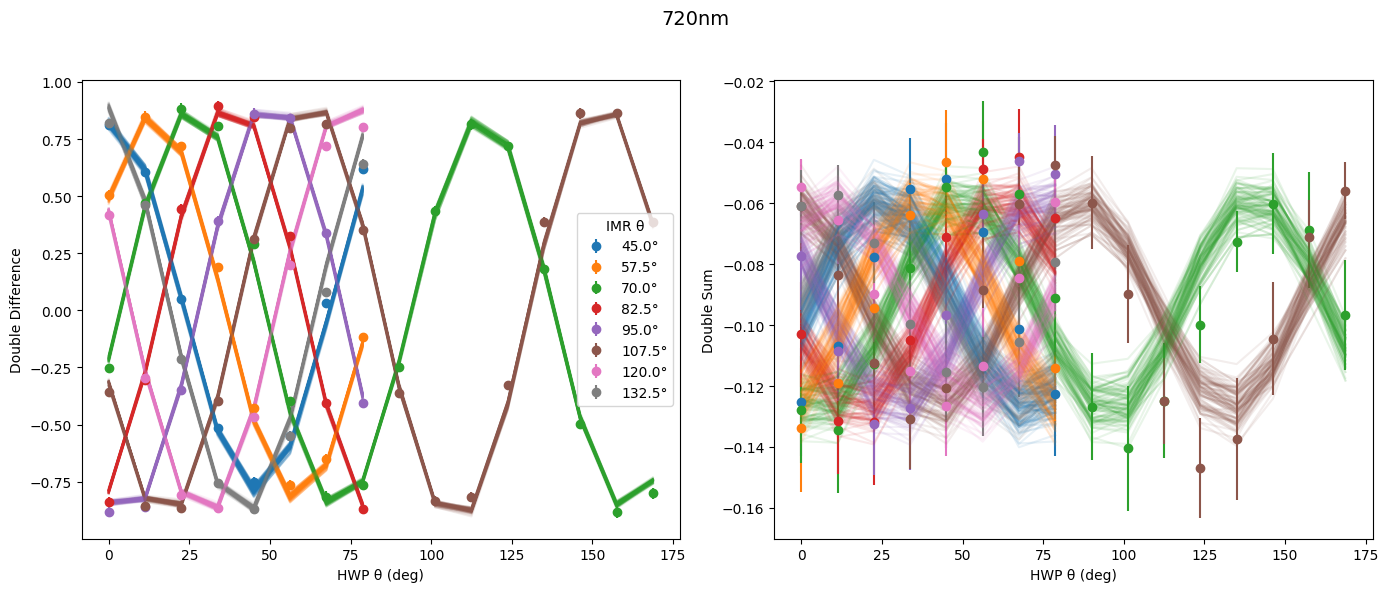

In [8]:
import importlib
inst = importlib.reload(inst)

# User settings
n_random_chains = 100
random_chain_step_range = corner_plot_step_range
random_chain_alpha = 0.1
random_seed = 42
imr_theta_filter = None

with open(txt_file_path, "r") as f:
    fit_param_dict = json.load(f)
_, fit_param_keys = inst.parse_configuration(fit_param_dict)

start, end = random_chain_step_range
if end is None:
    end = chain.shape[0]

if start < 0 or end > chain.shape[0] or start >= end:
    raise ValueError(f"Invalid random_chain_step_range {random_chain_step_range} for chain with {chain.shape[0]} steps.")

chain_window = chain[start:end, :, :]
flat_chain_window = chain_window.reshape(-1, chain.shape[-1])
n_available_samples = flat_chain_window.shape[0]

if chain.shape[-1] < len(fit_param_keys):
    raise ValueError(f"Chain has {chain.shape[-1]} parameters, but {len(fit_param_keys)} fitted parameters were found.")

if n_random_chains > n_available_samples:
    raise ValueError(f"Only {n_available_samples} samples available, but {n_random_chains} requested.")

rng = np.random.default_rng(random_seed)
selected_flat_indices = rng.choice(n_available_samples, size=n_random_chains, replace=False)
selected_steps = start + (selected_flat_indices // chain.shape[1])
selected_walkers = selected_flat_indices % chain.shape[1]
random_chain_samples = flat_chain_window[selected_flat_indices, :len(fit_param_keys)]
random_chain_system_mm = inst.generate_system_mueller_matrix(system_dict)
s_in_random = globals().get("s_in", np.array([1, 0, 0, 0]))

random_chain_models = [
    inst.model(
        sample,
        fit_param_keys,
        random_chain_system_mm,
        configuration_list,
        s_in=s_in_random,
        process_model=inst.process_model,
    )
    for sample in random_chain_samples
]

print(f"Plotting {n_random_chains} random chain samples from steps {start} to {end}.")
print("Selected (step, walker) pairs:")
print(list(zip(selected_steps.tolist(), selected_walkers.tolist())))

inst.plot_data_and_model(
    interleaved_values,
    interleaved_stds,
    random_chain_models,
    configuration_list,
    wavelength=wavelength_string,
    imr_theta_filter=imr_theta_filter,
    model_alpha=random_chain_alpha,
    first_model_alpha=random_chain_alpha,
)


In [9]:
# import sys
# import os

# # Add the directory containing instruments.py to the Python path
# custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
# sys.path.append(custom_module_path)

# import plotting_rewrite as plotting
# import numpy as np

# all_step_range = (0, None)
# corner_plot_step_range = (24000, 25000)

# # Define the system configuration dictionary
# system_dict = {
#     "components": {
#         "wollaston": {
#             "type": "wollaston_prism_function",
#             "properties": {"beam": "o", "transmission_ratio": 1.18},
#         },
#         "dichroic": {
#             "type": "diattenuator_retarder_function",
#             "properties": {"phi": 0, "epsilon": 0, "theta": 0},
#         },
#         "flc": {
#             "type": "general_retarder_function",
#             "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
#         },
#         "optics": {
#             "type": "diattenuator_retarder_function",
#             "properties": {"phi": 0, "epsilon": 0, "theta": 0},
#         },
#         "image_rotator": {
#             "type": "general_retarder_function",
#             "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
#         },
#         "hwp": {
#             "type": "general_retarder_function",
#             "properties": {"phi": 0.5, "theta": 0, "delta_theta": 0},
#         },
#         "lp": {
#             "type": "general_linear_polarizer_function_with_theta",
#             "properties": {"theta": 0},
#         },
#     }
# }

# # Input paths and call plotting function
# h5_filename = "675nm_no_IMR_offset_with_dichroic.h5"
# txt_filename = "675-50nm.txt"
# csv_file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"

# plotting.plot_mcmc_fits_double_diff_sum(
#     h5_filename=h5_filename,
#     txt_filename=txt_filename,
#     csv_path=csv_file_path,
#     filter_wavelength="675-50",
#     system_dict=system_dict,
#     wavelength_str="675nm",
#     n_samples=50,
#     step_range = all_step_range
# )
